In [7]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.linalg as la
from scipy import interpolate
import scipy.integrate as integrate

#1.

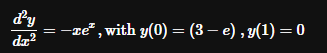


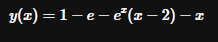

In [54]:
def EDP(N, f, xa, xb, Ua, Ub):
  h = (xb - xa) / (N - 1)
  xi = np.linspace(xa, xb, N)
  u = np.zeros(N , float);
  b = np.zeros(N, float );

  #steps: elements, malla
  xi = np.linspace(xa, xb, N)
  # A matrix (integrated analytical)
  A = np.zeros((N, N), float );
  for i in range( 1 , N):
      A[i-1,i-1] = A[i-1,i-1] + 1/ h
      A[i-1,i] = A[i-1,i] - 1/h
      A[i,i-1] = A[i-1,i]
      A[i,i]= A[i,i] + 1/ h


  #phi(x) functions
  def lin1(x, x1, x2):
      return (x-x1)/(x2-x1)

  def lin2(x, x1, x2):
      return (x2-x)/(x2-x1)

  #integrals for bi elements using quad
  def int1(min, max):
      return integrate.quad(lambda x: f(x)*lin1(x, min, max), min, max)[0]

  def int2(min, max):
      return integrate.quad(lambda x: f(x)*lin2(x, min, max), min, max)[0]
  b = np.zeros(N, float);

  for i in range(1,N):
    b[i-1] += int2(xi[i-1], xi[i])
    b[i]   += int1(xi[i-1], xi[i])



  #Initial conditions
  A[0, :] = 0
  A[0, 0] = 1
  b[0] = Ua

  A[N-1, :] = 0
  A[N-1, N-1] = 1
  b[N-1] = Ub
  sol = np.linalg.solve(A, b )
  x_new = np.linspace(xa,xb)
  y_new = np.interp(x_new, xi, sol)
  return x_new, y_new, sol,xi

In [51]:
def y_analitica( x ):
    u = 1-np.exp(1)+np.exp(x)*(2-x)-x
    return u

In [55]:
X, Y, sol, x_nodos= EDP(11,lambda x: x*np.exp(x),0,1, 3-np.e , 0.0  )

/tmp/ipykernel_13050/522721571.py:2: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "co" (-> color='c'). The keyword argument will take precedence.
  plt.plot(X, y_analitica(X),'co', c = "cyan" , label='Exact Solution')


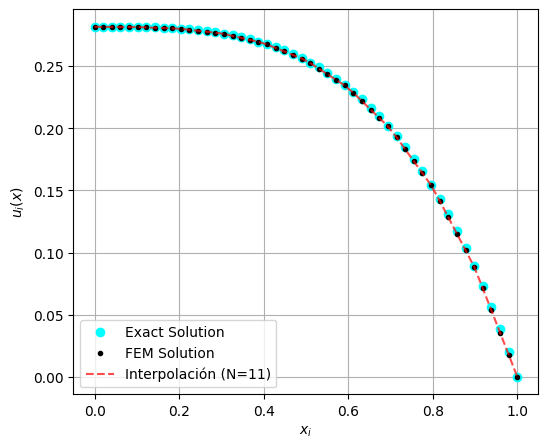

In [58]:
plt.figure(figsize=(6, 5))
plt.plot(X, y_analitica(X),'co', c = "cyan" , label='Exact Solution')
plt.plot(X, Y,'k.', label='FEM Solution')
plt.plot(X, Y, label=f"Interpolación (N={11})", color="red", linestyle="--", alpha=0.7)
plt.xlabel(r'$x_i$')
plt.ylabel(r'$u_i(x)$')
plt.legend(loc='best')
plt.grid()
plt.show()

#2:

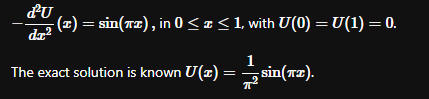

In [59]:
def y2(x):
  u = (1./np.pi**2)*np.sin(np.pi*x)
  return u

In [62]:
X,Y,sol,x_nodos=EDP(11,lambda x: np.sin(np.pi*x),0,1,0,0)

/tmp/ipykernel_13050/3017387062.py:2: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "co" (-> color='c'). The keyword argument will take precedence.
  plt.plot(X, y2(X),'co', c = "cyan" , label='Exact Solution')


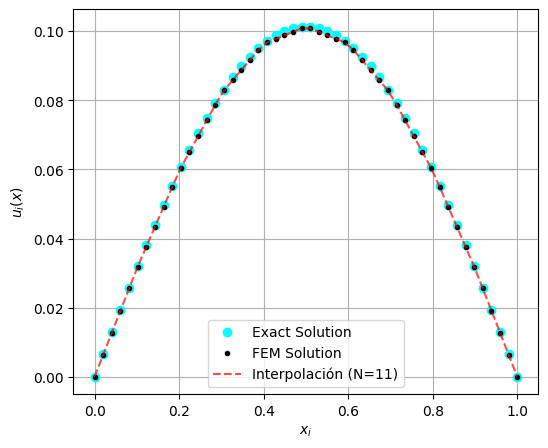

In [63]:
plt.figure(figsize=(6, 5))
plt.plot(X, y2(X),'co', c = "cyan" , label='Exact Solution')
plt.plot(X, Y,'k.', label='FEM Solution')
plt.plot(X, Y, label=f"Interpolación (N={11})", color="red", linestyle="--", alpha=0.7)
plt.xlabel(r'$x_i$')
plt.ylabel(r'$u_i(x)$')
plt.legend(loc='best')
plt.grid()
plt.show()